# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
# Library essential
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Library pre-processing data
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA

# Library ML
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Library save model (joblib)
import joblib

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
print("Ok")

Ok


In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

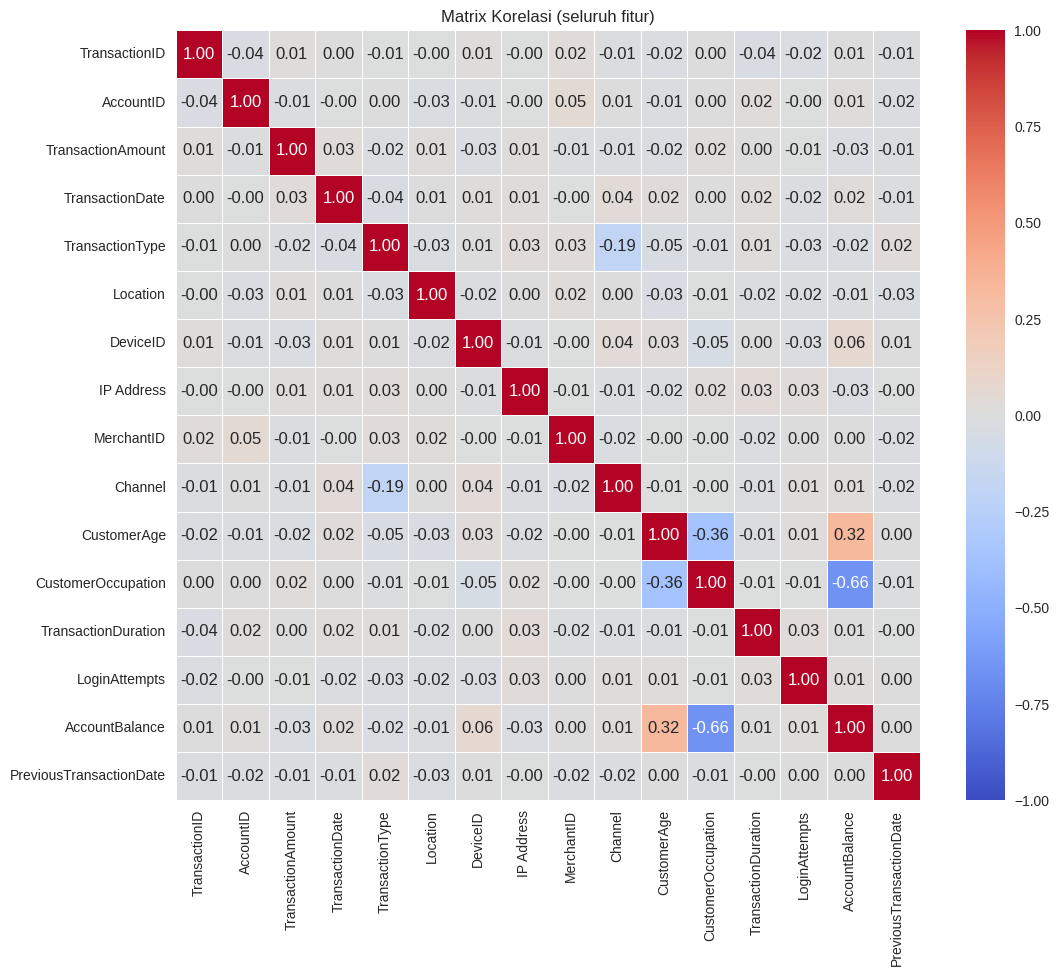

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Encode fitur non-numerik (kategorikal) agar bisa dicari korelasi antar variabel (sementara)
label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df)

# Pilih fitur kategorikal (dtype berupa object) untuk di-encode
category_features = df.select_dtypes(include=['object']).columns
for col in category_features:
    df_lencoder[col] = label_encoder.fit_transform(df[col])

plt.figure(figsize=(12, 10))
matrix_korelasi = df_lencoder.corr() # Method corr() milik DataFrame untuk mencari korelasi antar variabel

sns.heatmap(matrix_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrix Korelasi (seluruh fitur)')
plt.show()

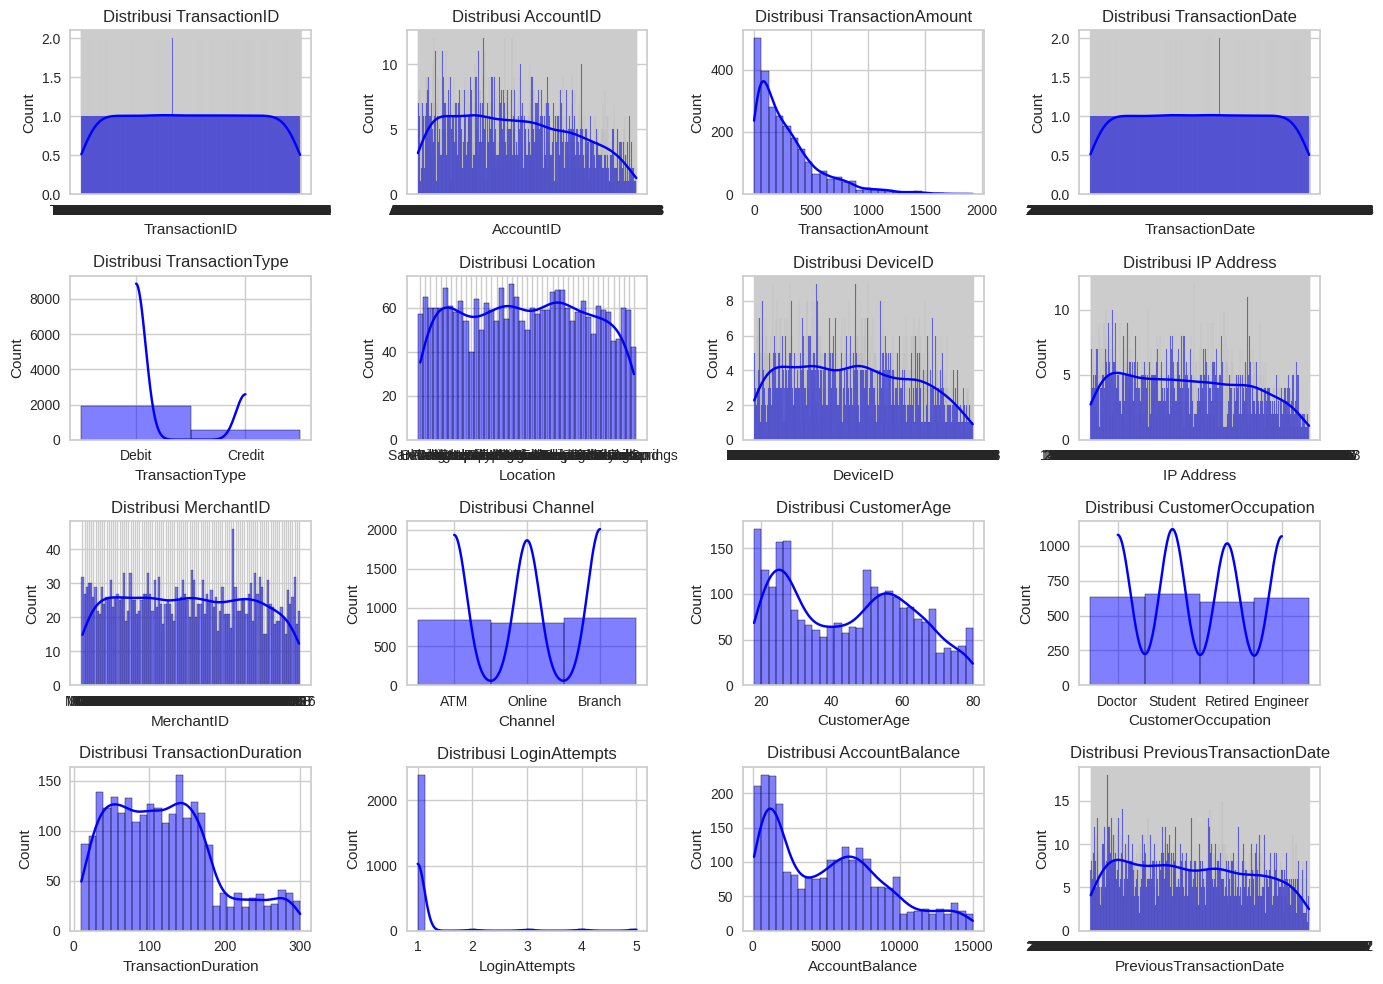

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

plt.figure(figsize=(14, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [9]:
# Mengecek dataset menggunakan isnull().sum()

missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [10]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [11]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.

# MinMaxScaler digunakan untuk menjadikan nilai menjadi dalam range 0-1
scaler = MinMaxScaler()

# Memilih kolom numerik untuk di-MinMax
numerik = df.select_dtypes(include=['int64', 'float64']).columns
df[numerik] = scaler.fit_transform(df[numerik])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,0.007207,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,0.838710,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,TX000002,AC00455,0.195940,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,0.806452,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,TX000003,AC00019,0.065680,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,0.016129,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,TX000004,AC00070,0.096016,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,0.129032,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,TX000005,AC00411,0.006874,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [12]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df = df.drop(columns=['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID'])
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,Debit,San Diego,ATM,0.838710,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,Debit,Houston,ATM,0.806452,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,Debit,Mesa,Online,0.016129,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,Debit,Raleigh,Online,0.129032,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,Credit,Atlanta,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [13]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

# Fitur kategorikal dipilih dengan mencari kolom dengan tipe data objek (termasuk tanggal)
kategorikal = df.select_dtypes(include=['object']).columns
encoders = {}

# LabelEncoder digunakan untuk men-encode fitur kategorikal ke numerik
for col in kategorikal:
  label_encoder = LabelEncoder()
  df[col] = label_encoder.fit_transform(df[col])
  # Encoder setiap kolom disimpan ke dictionary agar bisa dikembalikan ke nilai awal
  encoders[col] = label_encoder

df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,680,1,36,0,0.838710,0,0.244828,0.0,0.336832,105
1,0.195940,1178,1,15,0,0.806452,0,0.451724,0.0,0.918055,192
2,0.065680,1262,1,23,2,0.016129,3,0.158621,0.0,0.068637,41
3,0.096016,818,1,33,2,0.129032,3,0.051724,0.0,0.569198,163
4,0.006874,1939,0,1,2,NaN,3,0.648276,0.0,0.492591,16


In [14]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [15]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).

# Cek lagi, siapa tahu ada perubahan jumlah kolom sejak kolom ID & IP di-drop
# missing_values = df.isnull().sum()
# missing_values[missing_values > 0]

# Ganti data hilang dengan mean (untuk numerik) & median (untuk kategorikal)
df[numerik] = df[numerik].fillna(df[numerik].mean())
df[kategorikal] = df[kategorikal].fillna(df[kategorikal].median())

missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [16]:
# Menghapus data duplikat menggunakan drop_duplicates().

df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [17]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
print("Sebelum drop outlier:", df.shape)

for col in numerik:
  # Untuk setiap kolom, kuantil 1 dan 3 dicari untuk mendapatkan batas bawah & batas atas
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  batas_bawah = Q1 - 1.5 * IQR
  batas_atas = Q3 + 1.5 * IQR

  # Outlier = data yang di nilainya di bawah batas bawah/di atas batas atas
  outlier = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]
  df = df.drop(outlier.index)

print("Setelah drop outlier:", df.shape)

Sebelum drop outlier: (2515, 11)
Setelah drop outlier: (2267, 11)


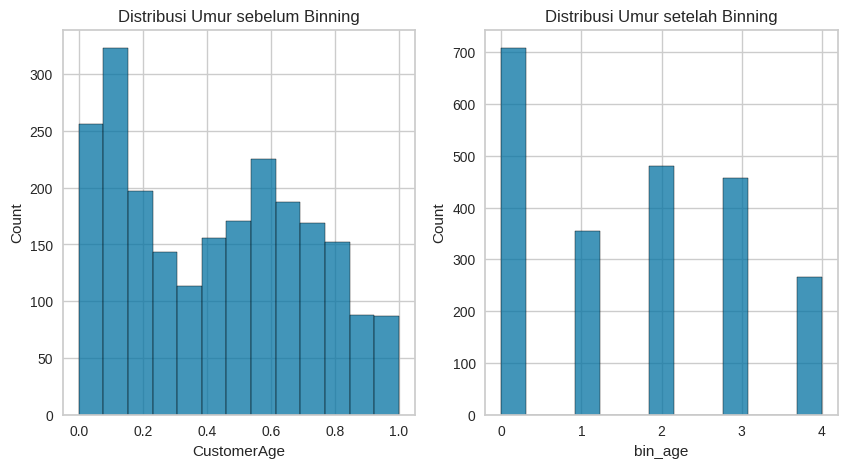

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,bin_age
0,0.007207,680,1,36,0,0.838710,0,0.244828,0.0,0.336832,105,4
1,0.195940,1178,1,15,0,0.806452,0,0.451724,0.0,0.918055,192,4
2,0.065680,1262,1,23,2,0.016129,3,0.158621,0.0,0.068637,41,0
3,0.096016,818,1,33,2,0.129032,3,0.051724,0.0,0.569198,163,0
4,0.006874,1939,0,1,2,0.430297,3,0.648276,0.0,0.492591,16,2


In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

# Fitur yang dipilih untuk di-bin: CustomerAge
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Distribusi Umur sebelum Binning')
sns.histplot(df['CustomerAge'])

# Coba bin ke 5 bin menggunakan method .cut() dari DataFrame
df['bin_age'] = pd.cut(df['CustomerAge'], bins=5)
# Setelah dipisah ke bin masing-masing, nilai binning di-encode & simpan ke dictionary
label_encoder = LabelEncoder()
df['bin_age'] = label_encoder.fit_transform(df['bin_age'])
encoders['CustomerAge'] = label_encoder

plt.subplot(1, 2, 2)
plt.title('Distribusi Umur setelah Binning')
sns.histplot(df['bin_age'])
plt.show()

df.head()

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,bin_age
count,2267.000000,2267.000000,2267.000000,2267.000000,2267.000000,2267.000000,2267.000000,2267.000000,2267.0,2267.000000,2267.000000,2267.000000
mean,0.133109,1254.011469,0.788708,21.344067,1.011910,0.429590,1.531098,0.375335,0.0,0.337183,180.419497,1.655492
std,0.112613,723.103838,0.439545,12.432512,0.827772,0.284355,1.147651,0.240138,0.0,0.259119,103.709767,1.399776
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.040806,632.500000,1.000000,11.000000,0.000000,0.145161,1.000000,0.182759,0.0,0.095788,92.000000,0.000000
50%,0.104787,1252.000000,1.000000,21.000000,1.000000,0.435484,2.000000,0.351724,0.0,0.319879,180.000000,2.000000
75%,0.193968,1877.500000,1.000000,32.000000,2.000000,0.661290,3.000000,0.520690,0.0,0.504446,270.500000,3.000000
max,0.467223,2485.000000,2.000000,43.000000,3.000000,1.000000,4.000000,1.000000,0.0,1.000000,360.000000,4.000000


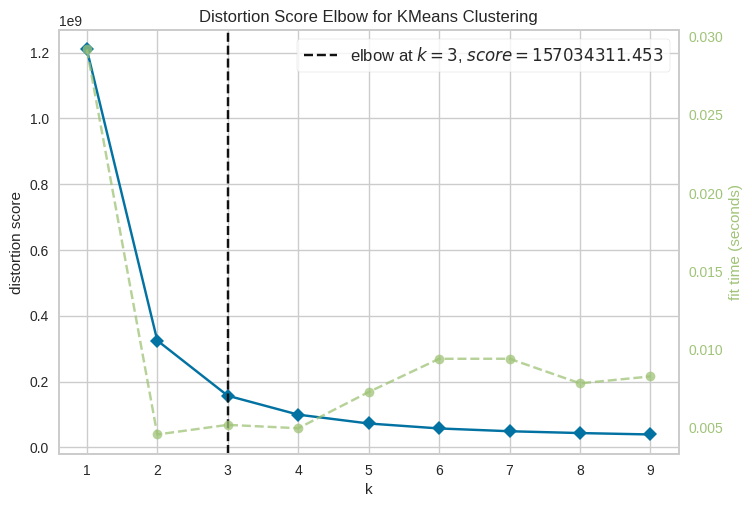

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

kmeans = KMeans()
# KElbowVisualizer digunakan untuk mencari jumlah cluster terbaik untuk clustering; ditemukan 3 cluster
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
visualizer.fit(df)
visualizer.show()

In [21]:
# Menggunakan algoritma K-Means Clustering

# Algoritma K-Means mem-fit data dan mencetak label ke DataFrame dengan nama kolom 'Target'

# note: random_state=42 digunakan agar hasil cluster (cluster 0, 1, atau 2) tidak berpindah-pindah
#       sehingga hasil interpretasi tetap sesuai. random_state tidak berpengaruh signifikan pada hasil akhir.

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df)
labels = kmeans.labels_

Jalankan cell code ini untuk menyimpan model kamu.

In [22]:
# Menyimpan model menggunakan joblib
# import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.
ss = silhouette_score(df, labels)
print("Silhouette Score =", ss)

Silhouette Score = 0.5408416568587009


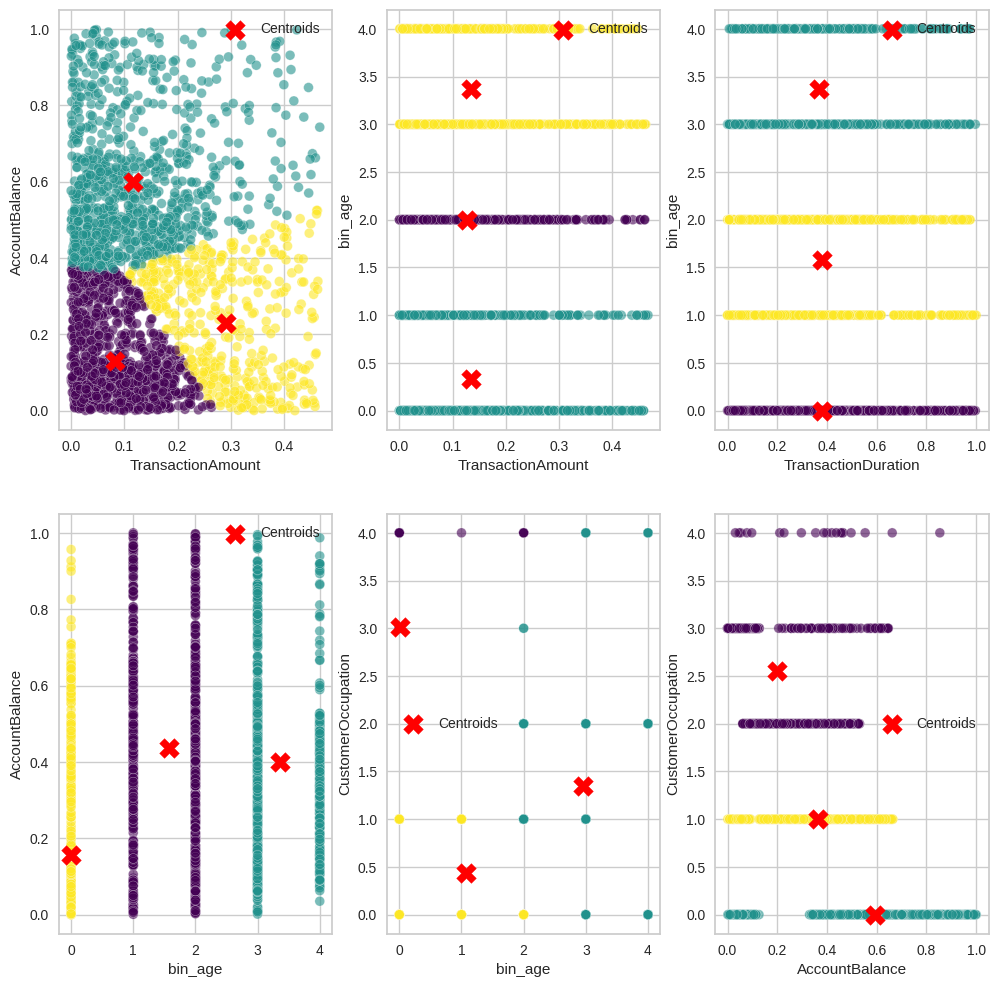

In [24]:
# Membuat visualisasi hasil clustering

# Fitur yang divisualisasi, yaitu sebanyak 6 kombinasi berbeda
# 3 kombinasi terakhir merupakan fitur dengan korelasi yang besar pada heatmap
fitur_tes = [
    ['TransactionAmount', 'AccountBalance'],
    ['TransactionAmount', 'bin_age'],
    ['TransactionDuration', 'bin_age'],
    ['bin_age', 'AccountBalance'],
    ['bin_age', 'CustomerOccupation'],
    ['AccountBalance', 'CustomerOccupation']]

plt.figure(figsize=(12,12))

for index, fitur in enumerate(fitur_tes):
  sumbu_x = fitur[0]
  sumbu_y = fitur[1]
  X_visual = df[fitur].values

  # K-Means dijalankan lagi dengan 2 variabel pilihan, khusus untuk melakukan visualisasi data
  # karena jika menggunakan K-Means 11 variabel, data saling overlap karena bisa ter-cluster pada dimensi yang berbeda
  kmeans_visual = KMeans(n_clusters=3)
  labels_visualisasi = kmeans_visual.fit_predict(X_visual)

  plt.subplot(2, 3, index+1)
  plt.scatter(df[sumbu_x], df[sumbu_y], c=labels_visualisasi, cmap='viridis',
            s=50, alpha=0.6, edgecolors='w', marker='o')
  centroids = kmeans_visual.cluster_centers_
  plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
  plt.title("")
  plt.xlabel(sumbu_x)
  plt.ylabel(sumbu_y)
  plt.legend()

plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [25]:
# Membangun model menggunakan PCA.
pca = PCA(n_components=2)
hasil_PCA = pca.fit_transform(df)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
df_PCA = pd.DataFrame(hasil_PCA, columns=['PCA1', 'PCA2'])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
kmeans_pca = KMeans(n_clusters=3)
kmeans_pca.fit(df_PCA)

KMeans(n_clusters=3)

In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

# Data di-group berdasarkan label Target cluster (0, 1, 2), kemudian
# dilakukan operasi mean, min, max, dan standar deviasi dari data per cluster
df_agg = df.copy()
df_agg['Target'] = labels
hasil = df_agg.groupby("Target")[numerik].agg(["mean", "min", "max"])
umur_bin = df_agg.groupby("Target")['bin_age'].agg(lambda x: x.mode()[0])
pd.concat([hasil, umur_bin], axis=1)


,"(TransactionAmount, mean)","(TransactionAmount, min)","(TransactionAmount, max)","(CustomerAge, mean)","(CustomerAge, min)","(CustomerAge, max)","(TransactionDuration, mean)","(TransactionDuration, min)","(TransactionDuration, max)","(LoginAttempts, mean)","(LoginAttempts, min)","(LoginAttempts, max)","(AccountBalance, mean)","(AccountBalance, min)","(AccountBalance, max)",bin_age
Target,,,,,,,,,,,,,,,,
0,0.137682,0.000031,0.463809,0.446350,0.0,1.0,0.377990,0.0,0.996552,0.0,0.0,0.0,0.330860,0.001125,0.997144,0
1,0.131026,0.000313,0.457759,0.412183,0.0,1.0,0.366390,0.0,0.996552,0.0,0.0,0.0,0.334129,0.000064,0.997633,0
2,0.130511,0.000000,0.467223,0.430023,0.0,1.0,0.381707,0.0,1.000000,0.0,0.0,0.0,0.346822,0.000000,1.000000,0


In [28]:
# Cell tambahan untuk melihat rata-rata total seluruh data, untuk membandingkan dengan nilai per cluster.
df[numerik].describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2267.000000,2267.000000,2267.000000,2267.0,2267.000000
mean,0.133109,0.429590,0.375335,0.0,0.337183
std,0.112613,0.284355,0.240138,0.0,0.259119
min,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.040806,0.145161,0.182759,0.0,0.095788
50%,0.104787,0.435484,0.351724,0.0,0.319879
75%,0.193968,0.661290,0.520690,0.0,0.504446
max,0.467223,1.000000,1.000000,0.0,1.000000


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: (Nasabah Senior dengan Transaksi di Atas Rata-rata dan Saldo Rata-rata)**:
  - **Rata-rata (mean) TransactionAmount:** 0.137682
  - **Rata-rata (mean) CustomerAge:** 0.446350
  - **Rata-rata (mean) TransactionDuration:** 0.377990
  - **Rata-rata (mean) LoginAttempts:** 0.0
  - **Rata-rata (mean) AccountBalance:** 0.330860
  - **Modus CustomerAge (bin):** 0
  - **Analisis:** Cluster ini memiliki rata-rata jumlah transaksi sedikit di atas rata-rata total dan dengan rata-rata umur yang lebih tua. Durasi transaksi yang dilakukan mendekati rata-rata total. Saldo akun pada nasabah di cluster ini paling rendah ketimbang cluster lain. Mayoritas range umur pada cluster ini ada pada bin 0, sama seperti cluster lain.

2. **Cluster 2: (Nasabah Muda dengan Saldo dan Transaksi Sekitar Rata-rata)**:
  - **Rata-rata (mean) TransactionAmount:** 0.131026
  - **Rata-rata (mean) CustomerAge:** 0.412183
  - **Rata-rata (mean) TransactionDuration:** 0.366390
  - **Rata-rata (mean) LoginAttempts:** 0.0
  - **Rata-rata (mean) AccountBalance:** 0.334129
  - **Modus CustomerAge (bin):** 0
  - **Analisis:** Cluster ini memiliki rata-rata jumlah transaksi yang mendekati rata-rata total. Rata-rata umur pada cluster ini paling muda ketimbang cluster lain dan dengan durasi transaksi lebih cepat dibandingkan cluster lain. Untuk saldo akun, cluster ini memiliki saldo yang juga mendekati rata-rata total. Mayoritas range umur pada cluster ini ada pada bin 0, sama seperti cluster lain.

3. **Cluster 3: (Nasabah dengan Umur Rata-rata, Saldo Tinggi, namun Transaksi di Bawah Rata-rata)**:
  - **Rata-rata (mean) TransactionAmount:** 0.130511
  - **Rata-rata (mean) CustomerAge:** 0.430023
  - **Rata-rata (mean) TransactionDuration:** 0.381707
  - **Rata-rata (mean) LoginAttempts:** 0.0
  - **Rata-rata (mean) AccountBalance:** 0.346822
  - **Modus CustomerAge (bin):** 0
  - **Analisis:** Cluster ini memiliki rata-rata jumlah transaksi sedikit di bawah rata-rata total. Rata-rata umur pada cluster hampir tepat pada rata-rata total dan durasi transaksi yang dilakukan lebih lama ketimbang rata-rata total. Saldo nasabah di cluster ini berada cukup jauh di atas rata-rata total. Mayoritas range umur pada cluster ini ada pada bin 0, sama seperti cluster lain.


# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [29]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df['Target'] = labels
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2267 entries, 0 to 2535
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        2267 non-null   float64
 1   TransactionDate          2267 non-null   int64  
 2   TransactionType          2267 non-null   int64  
 3   Location                 2267 non-null   int64  
 4   Channel                  2267 non-null   int64  
 5   CustomerAge              2267 non-null   float64
 6   CustomerOccupation       2267 non-null   int64  
 7   TransactionDuration      2267 non-null   float64
 8   LoginAttempts            2267 non-null   float64
 9   AccountBalance           2267 non-null   float64
 10  PreviousTransactionDate  2267 non-null   int64  
 11  bin_age                  2267 non-null   int64  
 12  Target                   2267 non-null   int32  
dtypes: float64(5), int32(1), int64(7)
memory usage: 239.1 KB


In [30]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [31]:
# inverse dataset ke rentang normal untuk numerikal
df_inverse = df.copy().drop(columns=['Target'])

df_inverse[numerik] = scaler.inverse_transform(df[numerik])
# tampilkan dataset yang sudah di-inverse
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,bin_age
0,14.09,680,1,36,0,70.000000,0,81.0,1.0,5112.21,105,4
1,376.24,1178,1,15,0,68.000000,0,141.0,1.0,13758.91,192,4
2,126.29,1262,1,23,2,19.000000,3,56.0,1.0,1122.35,41,0
3,184.50,818,1,33,2,26.000000,3,25.0,1.0,8569.06,163,0
4,13.45,1939,0,1,2,44.678444,3,198.0,1.0,7429.40,16,2


In [32]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)

for col in kategorikal:
  label_encoder = encoders[col]
  df_inverse[col] = label_encoder.inverse_transform(df_inverse[col].astype(int))

# Mengembalikan binning CustomerAge ke range yang sesuai
label_encoder = encoders['CustomerAge']
df_inverse['bin_age'] = label_encoder.inverse_transform(df['bin_age'])

# tampilkan dataset yang sudah di-inverse
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,bin_age
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.000000,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,"(0.8, 1.0]"
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.000000,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,"(0.8, 1.0]"
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.000000,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,"(-0.001, 0.2]"
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.000000,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,"(-0.001, 0.2]"
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,Online,44.678444,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,"(0.4, 0.6]"


In [33]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

df_agg_inverse = df_inverse.copy()
df_agg_inverse['Target'] = labels

numerik_inverse = df_agg_inverse.select_dtypes(include=['int64', 'float64']).columns
kategorikal_inverse = df_agg_inverse.select_dtypes(include=['object']).columns
binned_inverse = df_agg_inverse.select_dtypes(include=['interval']).columns

hasil_num = df_agg_inverse.groupby("Target")[numerik_inverse].agg(["mean", "min", "max"])
hasil_kat = df_agg_inverse.groupby("Target")[kategorikal_inverse].agg(lambda x: x.mode()[0])
hasil_bin = df_agg_inverse.groupby("Target")[binned_inverse].agg(lambda x: x.mode()[0])
hasil_num_kat = pd.concat([hasil_num, hasil_kat, hasil_bin], axis=1)

hasil_num_kat

,"(TransactionAmount, mean)","(TransactionAmount, min)","(TransactionAmount, max)","(CustomerAge, mean)","(CustomerAge, min)","(CustomerAge, max)","(TransactionDuration, mean)","(TransactionDuration, min)","(TransactionDuration, max)","(LoginAttempts, mean)",...,"(AccountBalance, mean)","(AccountBalance, min)","(AccountBalance, max)",TransactionDate,TransactionType,Location,Channel,CustomerOccupation,PreviousTransactionDate,bin_age
Target,,,,,,,,,,,,,,,,,,,,,
0,264.450541,0.32,890.24,45.673682,18.0,80.0,119.617188,10.0,299.0,1.0,...,5023.375491,117.98,14935.50,2023-05-09 16:54:49,Debit,Chicago,Branch,Retired,2024-11-04 08:07:18,"(-0.001, 0.2]"
1,251.678632,0.86,878.63,43.555340,18.0,80.0,116.253022,10.0,299.0,1.0,...,5071.998075,102.20,14942.78,2023-01-02 16:00:06,Debit,Los Angeles,Branch,Student,2024-11-04 08:10:23,"(-0.001, 0.2]"
2,250.691277,0.26,896.79,44.661410,18.0,80.0,120.694998,10.0,300.0,1.0,...,5260.830889,101.25,14977.99,2023-12-28 17:31:03,Debit,Omaha,Branch,Student,2024-11-04 08:07:16,"(-0.001, 0.2]"


In [34]:
# Cell tambahan untuk melihat rata-rata total seluruh data, untuk membandingkan dengan nilai per cluster.
df_agg_inverse.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,Target
count,2267.000000,2267.000000,2267.000000,2267.0,2267.000000,2267.000000
mean,255.676184,44.634554,118.847069,1.0,5117.436654,0.989413
std,216.088076,17.630036,69.639967,0.0,3854.847913,0.816248
min,0.260000,18.000000,10.000000,1.0,101.250000,0.000000
25%,78.560000,27.000000,63.000000,1.0,1526.265000,0.000000
50%,201.330000,45.000000,112.000000,1.0,4860.010000,1.000000
75%,372.455000,59.000000,161.000000,1.0,7605.765000,2.000000
max,896.790000,80.000000,300.000000,1.0,14977.990000,2.000000


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 1: (Nasabah Senior dengan Transaksi Besar dan Saldo Rata-rata)**:
  - **Rata-rata (mean) TransactionAmount:** 264.450541
  - **Rata-rata (mean) CustomerAge:** 45.673682
  - **Rata-rata (mean) TransactionDuration:** 119.617188
  - **Rata-rata (mean) LoginAttempts:** 0.0
  - **Rata-rata (mean) AccountBalance:** 5023.375491
  - **Modus CustomerAge (bin):** (-0.001, 0.2]
  - **Modus CustomerOccupation:** Retired
  - **Analisis:** Cluster ini memiliki rata-rata jumlah transaksi 264, yang lebih tinggi ketimbang cluster lain. Durasi transaksi yang dilakukan oleh cluster ini sedikit di atas rata-rata total, dan saldo nasabah paling rendah ketimbang cluster lain di 5023. Rata-rata umur di cluster ini merupakan yang paling tua pada umur 46, walau umur nasabah terbanyak berada di bin 0 (kelompok muda). Pekerjaan nasabah terbanyak di cluster ini merupakan pensiunan; sesuai dengan rata-rata umur mereka yang lebih tinggi dibanding cluster lain.

2. **Cluster 2: (Nasabah Muda dengan Saldo dan Transaksi Menengah)**:
  - **Rata-rata (mean) TransactionAmount:** 251.678632
  - **Rata-rata (mean) CustomerAge:** 43.555340
  - **Rata-rata (mean) TransactionDuration:** 116.253022
  - **Rata-rata (mean) LoginAttempts:** 0.0
  - **Rata-rata (mean) AccountBalance:** 5071.998075
  - **Modus CustomerAge (bin):** (-0.001, 0.2]
  - **Modus CustomerOccupation:** Student
  - **Analisis:** Cluster ini memiliki rata-rata jumlah transaksi sebanyak 252, yang mendekati rata-rata total (256). Durasi transaksi pada cluster ini lebih cepat dibandingkan cluster lain. Rata-rata saldo akun cluster ini sebanyak 5071, yang cukup dekat dengan rata-rata total (5117). Rata-rata umur di cluster ini paling muda ketimbang cluster lain pada umur 44, namun juga didominasi dengan nasabah bin 0 (kelompok muda). Sebagian nasabah memiliki pekerjaan sebagai pelajar.

3. **Cluster 3: (Nasabah dengan Saldo Tinggi namun Transaksi di bawah Menengah)**:
  - **Rata-rata (mean) TransactionAmount:** 250.691277
  - **Rata-rata (mean) CustomerAge:** 44.661410
  - **Rata-rata (mean) TransactionDuration:** 120.694998
  - **Rata-rata (mean) LoginAttempts:** 0.0
  - **Rata-rata (mean) AccountBalance:** 5260.830889
  - **Modus CustomerAge (bin):** (-0.001, 0.2]
  - **Modus CustomerOccupation:** Student
  - **Analisis:** Cluster ini memiliki rata-rata jumlah transaksi pada 251, sedikit di bawah rata-rata total (256). Durasi transaksi cluster ini paling lama ketimbang cluster lain. Namun, saldo nasabah di cluster ini berada cukup jauh di atas rata-rata total, yaitu pada 5261. Rata-rata umur pada cluster jatuh di 44,6 tahun, tepat di tengah-tengah. Pekerjaan terbanyak nasabah adalah sebagai pelajar, dengan dominasi bin 0 (kelompok muda).

**Catatan Tambahan:** Pada ketiga cluster, tipe transaksi terbanyak dan channel terbanyak yang sama, yaitu tipe transaksi debit pada channel branch (cabang).



(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [35]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
df_inverse['Target'] = labels
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,bin_age,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.000000,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,"(0.8, 1.0]",1
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.000000,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,"(0.8, 1.0]",0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.000000,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,"(-0.001, 0.2]",0
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.000000,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,"(-0.001, 0.2]",1
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,Online,44.678444,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,"(0.4, 0.6]",2


In [36]:
# Simpan Data
df_inverse.to_csv('data_clustering_inverse.csv', index=False)

End of Code.